In [1]:
#Importing libraries
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

#Load data
conn = sqlite3.connect("churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)
print("Data loaded:", df.shape)

Data loaded: (7043, 21)


In [5]:
#Preparing data for ML model
df_model = df.copy()

#Drop customerID and customer_type
df_model = df_model.drop('customerID', axis=1)
if 'customer_type' in df_model.columns:
    df_model = df_model.drop('customer_type', axis=1)

#Convert target variable to 0/1
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

#Fix TotalCharges
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(df_model['TotalCharges'].median())

#Convert ALL remaining object columns using get_dummies
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Converting these columns:", cat_cols)
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("\nReady for ML! Shape:", df_model.shape)
print("Target distribution:\n", df_model['Churn'].value_counts())

Converting these columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Ready for ML! Shape: (7043, 31)
Target distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [6]:
#Splitting data into train and test
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5634, 30)
Testing set size: (1409, 30)


In [8]:
#Training Logistic Regression model
lr_model = LogisticRegression(max_iter=3000)
lr_model.fit(X_train, y_train)

#Predictions
y_pred = lr_model.predict(X_test)

#Results
print("=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Logistic Regression Results ===
Accuracy: 82.19 %

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



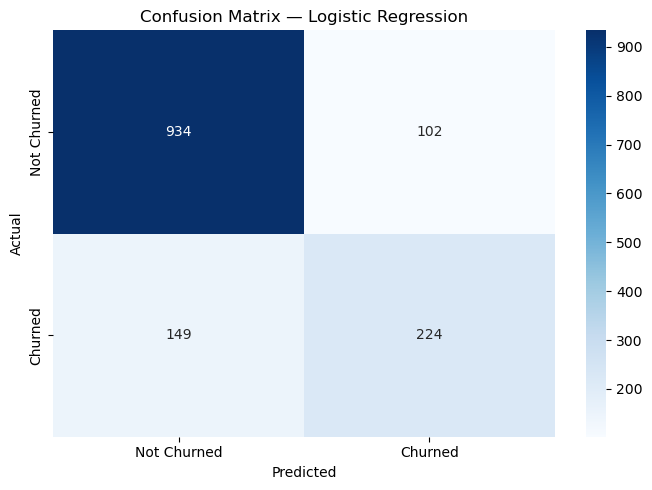

In [9]:
#Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

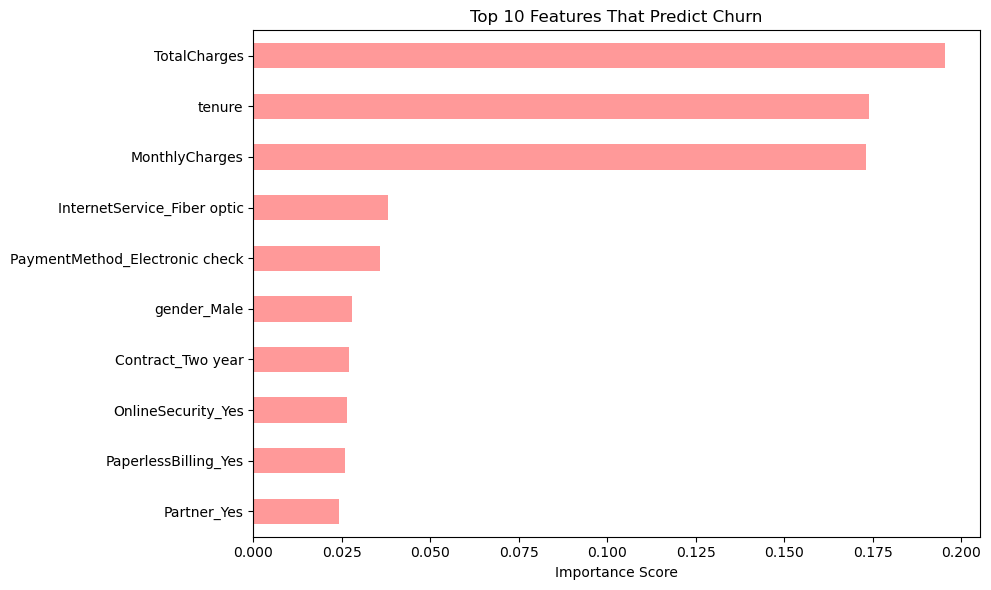

In [10]:
#Feature Importance using Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Plot top 10 features
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importance.nlargest(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='#ff9999')
plt.title('Top 10 Features That Predict Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()